# Análisis de Datos y Reducción de Dimensionalidad


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")

pd.set_option('display.max_columns', None)
import warnings; warnings.filterwarnings("ignore")

## 1. Carga de Datos

In [ ]:
train_data = pd.read_csv("../data/training_data_processed.csv")

train_data.head()

Cargando datos de entrenamiento procesados...


,price,automatic_relist,initial_quantity,sold_quantity,local_pick_up,free_shipping,Visa Electron,Mastercard Maestro,Acordar con el comprador,Transferencia bancaria,Visa,Contra reembolso,MasterCard,Cheque certificado,Tarjeta de crédito,Giro postal,Diners,Efectivo,American Express,MercadoPago,items_variation,available_quantity_variation,bronze,silver,free,gold_special,gold,gold_premium,gold_pro,buy_it_now,classified,auction,dragged_bids_and_visits,good_quality_thumbnail,dragged_visits,free_relist,poor_quality_thumbnail,sin_tag,is_official_store,custom,not_specified,me1,me2,sin_garantia,garantia_especifica,state_grouped_Capital Federal,state_grouped_Córdoba,state_grouped_Mendoza,state_grouped_Otros,state_grouped_Santa Fe,probabilidad_new,probabilidad_used,condition
0,80.0,0,1,0,1,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0.0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0.812019,0.187981,0
1,2650.0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0.0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,1,0,0,0,0,0.662169,0.337831,1
2,60.0,0,1,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0.0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0.001765,0.998235,1
3,580.0,0,1,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0.0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,1,0,0,0,0,0.993042,0.006958,0
4,30.0,0,1,0,1,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0.0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0.060174,0.939826,1


In [ ]:
X_train = train_data.drop('condition', axis=1)
y_train = train_data['condition']

print(f"Verificar otra vez el balanceDistribución de clases:")
print(y_train.value_counts())

Features shape: (96704, 52)
Target shape: (96704,)

Distribución de clases:
condition
0    48352
1    48352
Name: count, dtype: int64


## 2. Análisis de Correlaciones

In [ ]:
correlation_matrix = X_train.corr()

high_corr_pairs = []
threshold = 0.8

for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > threshold:
            high_corr_pairs.append({
                'feature1': correlation_matrix.columns[i],
                'feature2': correlation_matrix.columns[j],
                'correlation': corr_value
            })

print(f"\nPares de variables con correlación > {threshold}:")
for pair in high_corr_pairs:
    print(f"{pair['feature1']} - {pair['feature2']}: {pair['correlation']:.3f}")

print(f"\nTotal de pares altamente correlacionados: {len(high_corr_pairs)}")

Calculando matriz de correlación...

Pares de variables con correlación > 0.8:
Visa Electron - Mastercard Maestro: 0.955
Visa Electron - Visa: 0.947
Visa Electron - MasterCard: 0.951
Visa Electron - Diners: 0.821
Visa Electron - American Express: 0.903
Mastercard Maestro - Visa: 0.937
Mastercard Maestro - MasterCard: 0.957
Mastercard Maestro - Diners: 0.825
Mastercard Maestro - American Express: 0.911
Visa - MasterCard: 0.957
Visa - Diners: 0.811
Visa - American Express: 0.915
MasterCard - Diners: 0.827
MasterCard - American Express: 0.928
Diners - American Express: 0.858
buy_it_now - classified: -0.861
dragged_bids_and_visits - sin_tag: -0.969
not_specified - me2: -0.933
sin_garantia - garantia_especifica: -1.000
probabilidad_new - probabilidad_used: -1.000

Total de pares altamente correlacionados: 20


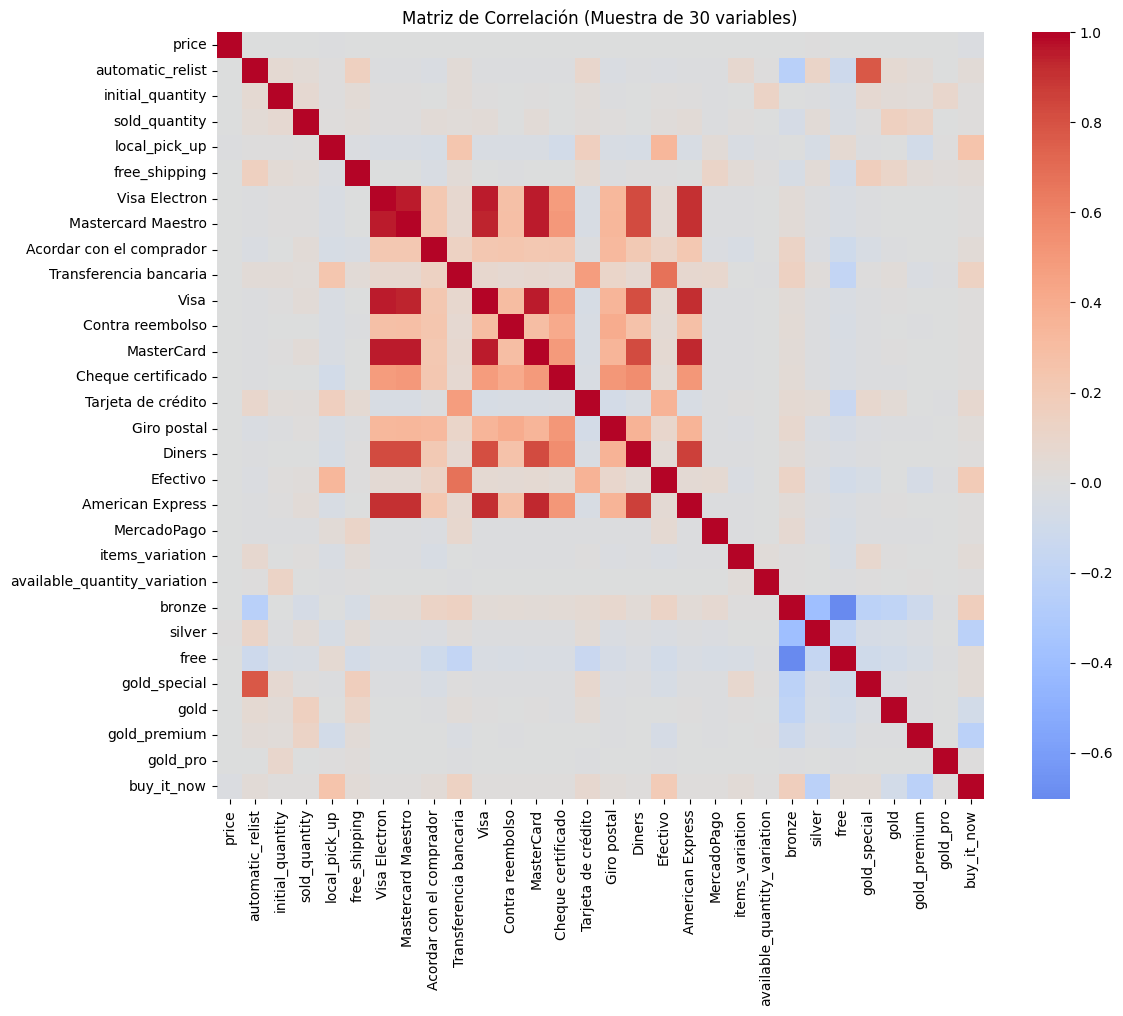

In [ ]:
plt.figure(figsize=(12, 10))

if len(X_train.columns) > 50:
    #Acá muestro solo 30 porqué si dejo todas las variables se ve muy pequeñito y no se logran entender bien las relaciones, pero en realidad
    #Lo mas correlacionado son las variables bancarias, ya lo habia mirado previamente
    sample_cols = X_train.columns[:30]
    corr_sample = X_train[sample_cols].corr()
    sns.heatmap(corr_sample, annot=False, cmap='coolwarm', center=0, 
                square=True, fmt='.2f')
    plt.title('Matriz de Correlación (Muestra de 30 variables)')
else:
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                square=True, fmt='.2f')
    plt.title('Matriz de Correlación Completa')

plt.tight_layout()
plt.show()

## 3. Análisis de Importancia de Features

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 features más importantes:")
print(feature_importance.head(20))

#Para este caso se utilizó el random solo por velocidad

Calculando importancia de features con Random Forest...

Top 20 features más importantes:
                          feature  importance
51              probabilidad_used    0.263354
50               probabilidad_new    0.261409
2                initial_quantity    0.114959
0                           price    0.090819
24                           free    0.081429
3                   sold_quantity    0.030370
22                         bronze    0.021886
44            garantia_especifica    0.013805
14             Tarjeta de crédito    0.009520
23                         silver    0.009461
45  state_grouped_Capital Federal    0.008766
9          Transferencia bancaria    0.007675
4                   local_pick_up    0.006969
43                   sin_garantia    0.006677
17                       Efectivo    0.006307
1                automatic_relist    0.006163
42                            me2    0.005194
40                  not_specified    0.005154
5                   free_shipping   

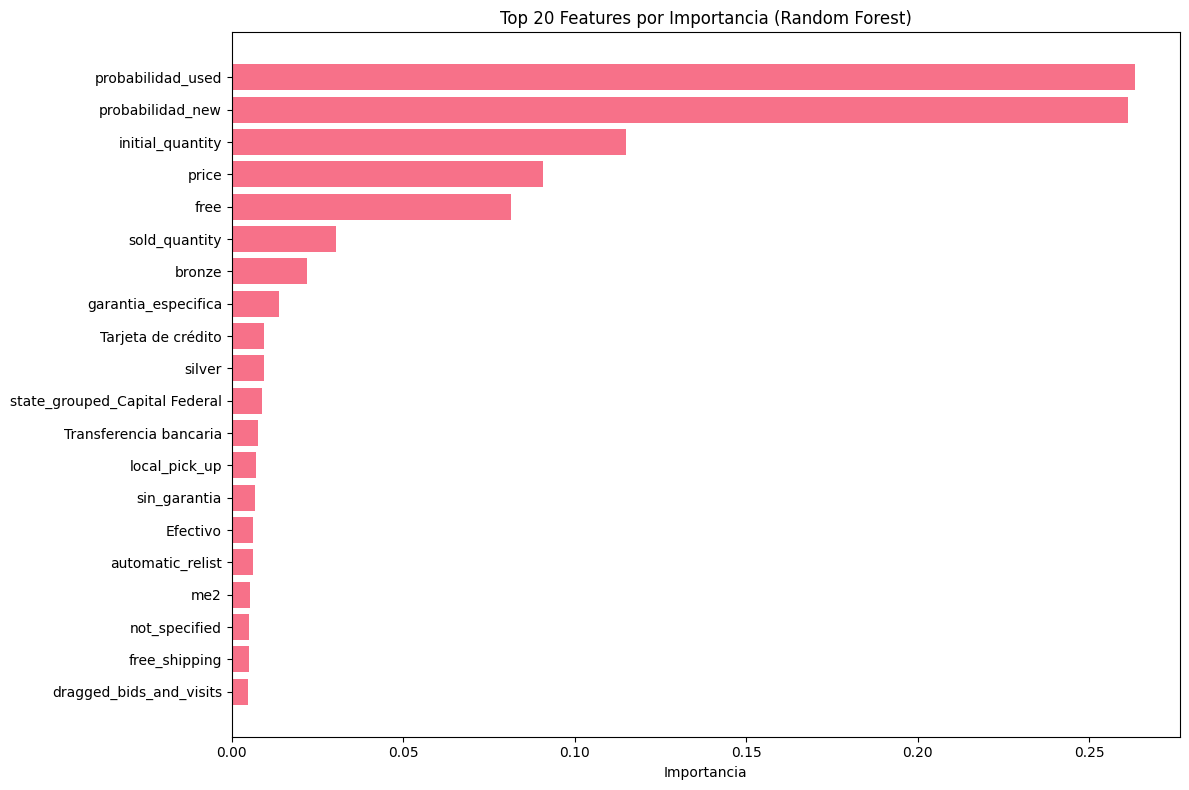

In [ ]:
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(20)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importancia')
plt.title('Top 20 Features por Importancia (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
#Utilizamos Anova para encontrar la importancia por medio del f score
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_train, y_train)

f_scores = pd.DataFrame({
    'feature': X_train.columns,
    'f_score': selector.scores_
}).sort_values('f_score', ascending=False)

print("Top 20 features por F-score:")
print(f_scores.head(20))

Calculando importancia con ANOVA F-test...

Top 20 features por F-score:
                   feature        f_score
51       probabilidad_used  110127.163523
50        probabilidad_new  110127.163454
24                    free   28242.490565
44     garantia_especifica    6132.943688
43            sin_garantia    6132.943688
22                  bronze    5071.354707
14      Tarjeta de crédito    4470.233025
1         automatic_relist    3804.560792
23                  silver    3107.216777
25            gold_special    2623.775171
9   Transferencia bancaria    2483.343106
5            free_shipping    2062.051162
26                    gold    1152.704615
33  good_quality_thumbnail     943.749657
20         items_variation     931.491612
29              buy_it_now     902.033975
40           not_specified     817.693892
30              classified     798.565020
38       is_official_store     673.157731
19             MercadoPago     654.734121


## 4. Análisis de Distribución de Features

In [ ]:
feature_variance = X_train.var().sort_values(ascending=False)
print("Features con mayor varianza:")
print(feature_variance.head(10))

print(f"\nFeatures con varianza cero: {sum(feature_variance == 0)}")
if sum(feature_variance == 0) > 0:
    zero_var_features = feature_variance[feature_variance == 0].index.tolist()
    print(f"Features con varianza cero: {zero_var_features}")

Features con mayor varianza:
price                            8.965908e+13
initial_quantity                 1.651519e+05
available_quantity_variation     2.162315e+03
sold_quantity                    1.066063e+03
items_variation                  1.098737e+00
Transferencia bancaria           2.499478e-01
me2                              2.499259e-01
not_specified                    2.481369e-01
state_grouped_Capital Federal    2.435450e-01
bronze                           2.345707e-01
dtype: float64

Features con varianza cero: 0


## 5. Preparación para PCA

In [ ]:
zero_var_features = feature_variance[feature_variance == 0].index.tolist()
if zero_var_features:
    print(f"Eliminando {len(zero_var_features)} features con varianza cero......")
    X_train_clean = X_train.drop(columns=zero_var_features)
else:
    X_train_clean = X_train.copy()

print(f"Shape después de limpiar: {X_train_clean.shape}")

Shape después de limpiar: (96704, 52)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)

print(f"Datos estandarizados. Shape: {X_train_scaled.shape}")
print(f"Media después de escalar: {X_train_scaled.mean():.6f}")
print(f"Std después de escalar: {X_train_scaled.std():.6f}")

Estandarizando datos...


Datos estandarizados. Shape: (96704, 52)
Media después de escalar: 0.000000
Std después de escalar: 1.000000


## 6. Análisis PCA

In [ ]:
pca_full = PCA()
pca_full.fit(X_train_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

variance_levels = [0.80, 0.85, 0.90, 0.95, 0.99]
components_needed = {}

for level in variance_levels:
    n_components = np.argmax(cumulative_variance >= level) + 1
    components_needed[level] = n_components
    print(f"Para {level*100}% de varianza: {n_components} componentes")

print(f"\nTotal de features originales: {X_train_scaled.shape[1]}")

Realizando PCA exploratorio...
Para 80.0% de varianza: 25 componentes
Para 85.0% de varianza: 28 componentes
Para 90.0% de varianza: 32 componentes
Para 95.0% de varianza: 36 componentes
Para 99.0% de varianza: 41 componentes

Total de features originales: 52


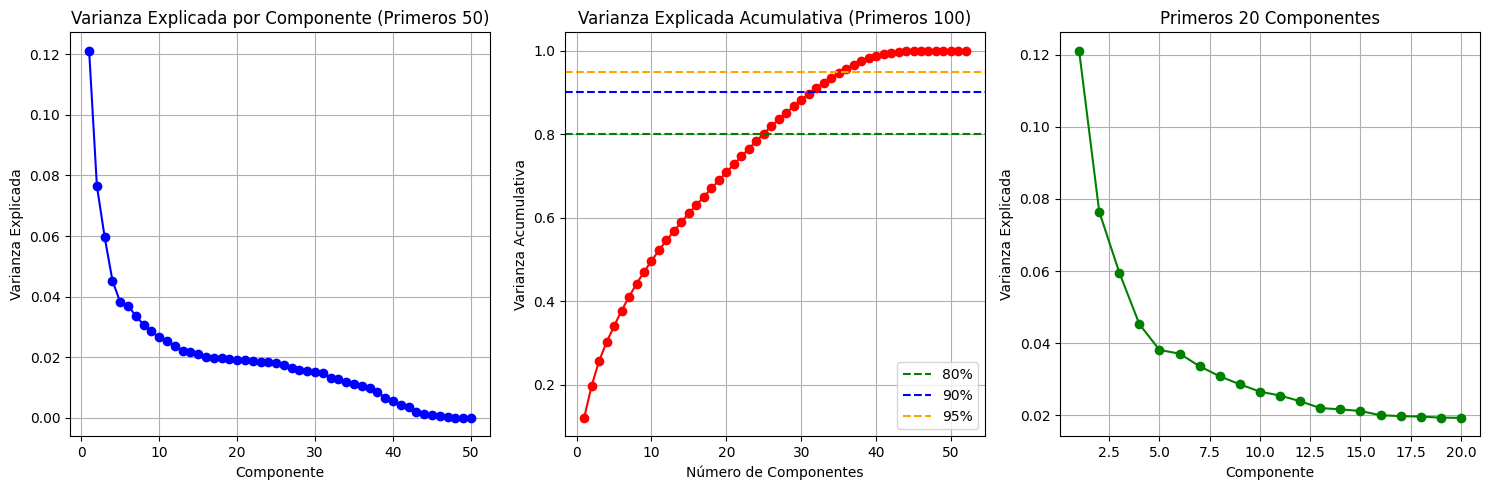

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(range(1, min(51, len(pca_full.explained_variance_ratio_) + 1)), 
         pca_full.explained_variance_ratio_[:50], 'bo-')
plt.xlabel('Componente')
plt.ylabel('Varianza Explicada')
plt.title('Varianza Explicada por Componente (Primeros 50)')
plt.grid(True)


plt.subplot(1, 3, 2)
plt.plot(range(1, min(101, len(cumulative_variance) + 1)), 
         cumulative_variance[:100], 'ro-')
plt.axhline(y=0.8, color='g', linestyle='--', label='80%')
plt.axhline(y=0.9, color='b', linestyle='--', label='90%')
plt.axhline(y=0.95, color='orange', linestyle='--', label='95%')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulativa')
plt.title('Varianza Explicada Acumulativa (Primeros 100)')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(range(1, min(21, len(pca_full.explained_variance_ratio_) + 1)), 
         pca_full.explained_variance_ratio_[:20], 'go-')
plt.xlabel('Componente')
plt.ylabel('Varianza Explicada')
plt.title('Primeros 20 Componentes')
plt.grid(True)

plt.tight_layout()
plt.show()

## 7. Aplicación de PCA con 90% de Varianza

In [ ]:
####el numero quedó como 90 en la variable porqué fue el que utilicé incialmente, pero el resultado emperó a otras iteraciones que habia hecho
####Por eso lo cambié a 95

target_variance = 0.95
n_components_90 = components_needed[target_variance]

print(f"Aplicando PCA con {n_components_90} componentes para {target_variance*100}% de varianza...")

pca_final = PCA(n_components=n_components_90, random_state=42)
X_train_pca = pca_final.fit_transform(X_train_scaled)

print(f"Shape original: {X_train_scaled.shape}")
print(f"Shape después de PCA: {X_train_pca.shape}")
print(f"Reducción de dimensionalidad: {X_train_scaled.shape[1] - X_train_pca.shape[1]} features eliminadas")
print(f"Varianza explicada real: {pca_final.explained_variance_ratio_.sum():.4f}")

Aplicando PCA con 36 componentes para 95.0% de varianza...
Shape original: (96704, 52)
Shape después de PCA: (96704, 36)
Reducción de dimensionalidad: 16 features eliminadas
Varianza explicada real: 0.9564


In [ ]:
pca_columns = [f'PC{i+1}' for i in range(n_components_90)]
train_pca_df = pd.DataFrame(X_train_pca, columns=pca_columns)
train_pca_df['condition'] = y_train.values

print("DataFrame de entrenamiento con PCA creado:")
print(f"Shape: {train_pca_df.shape}")
print(train_pca_df.head())

DataFrame de entrenamiento con PCA creado:
Shape: (96704, 37)
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0  0.339300  0.867675  0.723431 -1.417612 -0.455604 -1.715455 -0.252610   
1 -0.213307  1.144762 -2.382958 -0.017038  2.494937  2.076937 -0.836933   
2  0.010567  1.205492  1.680104 -0.800357 -0.805292  1.867579  0.277844   
3 -0.400082  0.766878 -1.796871  0.135521  2.752182  1.447875  0.319481   
4  0.380390 -0.098449  1.967906 -1.153425 -1.451713 -0.457838 -0.766349   

        PC8       PC9      PC10      PC11      PC12      PC13      PC14  \
0  1.036460  0.471007  0.717709  0.872508  0.588242  0.284871 -0.437826   
1 -1.322765  0.602160 -0.351822  0.211044  2.548472 -0.230975  0.623307   
2  0.932748  0.250514 -0.925972  0.389576 -0.641296 -0.134015  0.202105   
3  2.290787 -0.720223  0.106723 -0.151055  2.337231 -0.165609  0.624388   
4  0.417125  1.270005  0.939747 -0.032847 -0.594201 -0.018057 -0.027097   

       PC15      PC16      PC17     

## 8. Análisis de Componentes Principales

In [ ]:

print("Análisis de los primeros 5 componentes principales:")

for i in range(min(5, n_components_90)):
    print(f"\nComponente Principal {i+1}:")
    print(f"Varianza explicada: {pca_final.explained_variance_ratio_[i]:.4f}")
    
    component_weights = pd.DataFrame({
        'feature': X_train_clean.columns,
        'weight': np.abs(pca_final.components_[i])
    }).sort_values('weight', ascending=False)
    
    print("Top 5 features más influyentes:")
    for j, (_, row) in enumerate(component_weights.head(5).iterrows()):
        print(f"  {j+1}. {row['feature']}: {row['weight']:.4f}")

Análisis de los primeros 5 componentes principales:

Componente Principal 1:
Varianza explicada: 0.1211
Top 5 features más influyentes:
  1. MasterCard: 0.3790
  2. Mastercard Maestro: 0.3767
  3. Visa: 0.3756
  4. Visa Electron: 0.3751
  5. American Express: 0.3727

Componente Principal 2:
Varianza explicada: 0.0765
Top 5 features más influyentes:
  1. buy_it_now: 0.3223
  2. classified: 0.3147
  3. Transferencia bancaria: 0.2690
  4. Efectivo: 0.2499
  5. dragged_visits: 0.2318

Componente Principal 3:
Varianza explicada: 0.0596
Top 5 features más influyentes:
  1. probabilidad_used: 0.3169
  2. probabilidad_new: 0.3169
  3. automatic_relist: 0.2981
  4. gold_special: 0.2842
  5. garantia_especifica: 0.2497

Componente Principal 4:
Varianza explicada: 0.0452
Top 5 features más influyentes:
  1. gold_special: 0.3320
  2. automatic_relist: 0.2885
  3. is_official_store: 0.2863
  4. free: 0.2847
  5. dragged_visits: 0.2772

Componente Principal 5:
Varianza explicada: 0.0381
Top 5 featur

## 9. Aplicación a Datos de Test

In [ ]:
print("Cargando datos de test procesados...")
try:
    test_data = pd.read_csv("../data/test_data_processed.csv")
    print(f"Datos de test cargados. Shape: {test_data.shape}")
    

    print("Aplicando transformaciones a datos de test...")
    

    if zero_var_features:
        test_data_clean = test_data.drop(columns=zero_var_features, errors='ignore')
    else:
        test_data_clean = test_data.copy()
    
    print(f"Test data después de limpiar: {test_data_clean.shape}")
    

    X_test_scaled = scaler.transform(test_data_clean)
    
    X_test_pca = pca_final.transform(X_test_scaled)
    
    print(f"Test data después de PCA: {X_test_pca.shape}")
    
    test_pca_df = pd.DataFrame(X_test_pca, columns=pca_columns)
    
    print("DataFrame de test con PCA creado:")
    print(test_pca_df.head())
    
except FileNotFoundError:
    print("Archivo de test no encontrado. Asegúrate de haber ejecutado el procesamiento de test primero.")
    test_pca_df = None

Cargando datos de test procesados...
Datos de test cargados. Shape: (10000, 52)
Aplicando transformaciones a datos de test...
Test data después de limpiar: (10000, 52)
Test data después de PCA: (10000, 36)
DataFrame de test con PCA creado:
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -0.135653  0.461482  0.264024 -1.021603 -0.474406  1.338409 -2.181976   
1 -0.343786 -1.197085  0.766170 -0.169379 -1.027852 -2.268896  0.641497   
2 -0.203847 -0.287145  0.252247  0.077130 -0.707193 -0.871728  2.312230   
3  0.007581  1.126932  1.440359 -0.782283 -0.671895  1.614495  0.356277   
4 -0.169493  0.891632  0.214397 -1.034895  0.289807 -2.064327 -0.216184   

        PC8       PC9      PC10      PC11      PC12      PC13      PC14  \
0  1.772590  0.269717 -0.017363 -1.211974  1.540096 -1.026544  2.276800   
1 -0.975482 -0.243114 -0.333502  0.627890  0.066844 -0.295836  0.104132   
2 -1.129193 -0.824614  0.117682 -0.647233 -0.300137 -0.737069  0.563731   
3  0.9576

## 10. Guardado de Modelos y Datos

In [ ]:
print("Guardando modelos...")


joblib.dump(scaler, '../data/pca_scaler.joblib')
print("Scaler guardado en: ../data/pca_scaler.joblib")


joblib.dump(pca_final, '../data/pca_model.joblib')
print("Modelo PCA guardado en: ../data/pca_model.joblib")


model_info = {
    'zero_variance_features': zero_var_features,
    'n_components': n_components_90,
    'variance_explained': float(pca_final.explained_variance_ratio_.sum()),
    'original_features': X_train_clean.columns.tolist(),
    'pca_columns': pca_columns
}

joblib.dump(model_info, '../data/pca_info.joblib')
print("Información del modelo PCA guardada en: ../data/pca_info.joblib")

Guardando modelos...
Scaler guardado en: ../data/pca_scaler.joblib
Modelo PCA guardado en: ../data/pca_model.joblib
Información del modelo PCA guardada en: ../data/pca_info.joblib


In [ ]:
# Guardar datasets transformados .....
print("Guardando datasets transformados...")


train_pca_df.to_csv('../data/training_data_pca.csv', index=False)
print(f"Datos de entrenamiento con PCA guardados: ../data/training_data_pca.csv")
print(f"Shape: {train_pca_df.shape}")

if test_pca_df is not None:
    test_pca_df.to_csv('../data/test_data_pca.csv', index=False)
    print(f"Datos de test con PCA guardados: ../data/test_data_pca.csv")
    print(f"Shape: {test_pca_df.shape}")
else:
    print("No se pudieron guardar los datos de test (archivo no encontrado)")

Guardando datasets transformados...
Datos de entrenamiento con PCA guardados: ../data/training_data_pca.csv
Shape: (96704, 33)
Datos de test con PCA guardados: ../data/test_data_pca.csv
Shape: (10000, 32)


## 11. Resumen Final

In [1]:
print(f"Features originales: {X_train.shape[1]}")
print(f"Features después de limpieza: {X_train_clean.shape[1]}")
print(f"Componentes principales seleccionadas: {n_components_90}")
print(f"Reducción de dimensionalidad: {X_train_clean.shape[1] - n_components_90} features ({((X_train_clean.shape[1] - n_components_90) / X_train_clean.shape[1] * 100):.1f}%)")
print(f"Varianza explicada: {pca_final.explained_variance_ratio_.sum():.4f} ({pca_final.explained_variance_ratio_.sum()*100:.2f}%)")


print(f"Pares de variables con correlación > {threshold}: {len(high_corr_pairs)}")

print("Importancia de las features:")
print(feature_importance.head(10)[['feature', 'importance']].to_string(index=False))

NameError: name 'X_train' is not defined

## 12. Dataframe categorico nuevamente

#### Después de entrenar los modelos con el dataset de PCA, me di cuenta que empeoró en performance y costos de entrenamiento, especialmente porqué estoy usando modelos basados en arboles y estos se mueven especialmente bien con las categorias, por lo que cambio de estartegia nuevamente y entregaé las variables más importantes pero en categorico.
#### Cabe destacar que la variable que se genera a traves de los titulos puede convertirse en una sola categorica con una alta correlación con la condición, por lo que en otra iteración si me da el tiempo la dejo sola y me evito problemas y facilito el entrenamiento

In [ ]:
rf_scores_norm = (feature_importance['importance'] - feature_importance['importance'].min()) / (feature_importance['importance'].max() - feature_importance['importance'].min())
f_scores_norm = (f_scores['f_score'] - f_scores['f_score'].min()) / (f_scores['f_score'].max() - f_scores['f_score'].min())

combined_scores = pd.DataFrame({
    'feature': feature_importance['feature'],
    'rf_importance': feature_importance['importance'],
    'f_score': f_scores.set_index('feature').loc[feature_importance['feature'], 'f_score'].values,
    'rf_normalized': rf_scores_norm,
    'f_normalized': f_scores_norm.loc[f_scores['feature'].isin(feature_importance['feature'])].values,
})

combined_scores['combined_score'] = (combined_scores['rf_normalized'] + combined_scores['f_normalized']) / 2
combined_scores = combined_scores.sort_values('combined_score', ascending=False)

print("Top 20 features por score combinado:")
print(combined_scores.head(20)[['feature', 'rf_importance', 'f_score', 'combined_score']])


combined_scores['cumulative_importance'] = combined_scores['combined_score'].cumsum() / combined_scores['combined_score'].sum()

target_variability = 0.95
features_95_mask = combined_scores['cumulative_importance'] <= target_variability
n_features_95 = features_95_mask.sum()

if combined_scores.loc[features_95_mask, 'cumulative_importance'].max() < target_variability:
    n_features_95 += 1

selected_features_95 = combined_scores.head(n_features_95)['feature'].tolist()

print(f"\nFeatures seleccionadas para 95% de variabilidad: {n_features_95}")
print(f"Variabilidad acumulativa real: {combined_scores.head(n_features_95)['cumulative_importance'].max():.4f}")
print(f"Reducción de features: {len(X_train.columns) - n_features_95} ({((len(X_train.columns) - n_features_95) / len(X_train.columns) * 100):.1f}%)")

print(f"\nFeatures seleccionadas:")
for i, feature in enumerate(selected_features_95, 1):
    importance = combined_scores[combined_scores['feature'] == feature]['combined_score'].iloc[0]
    print(f"{i:2d}. {feature} (score: {importance:.4f})")

=== ANÁLISIS DE FEATURES PARA 95% DE VARIABILIDAD ===
Top 20 features por score combinado:
                          feature  rf_importance        f_score  \
51              probabilidad_used       0.263354  110127.163523   
50               probabilidad_new       0.261409  110127.163454   
2                initial_quantity       0.114959     551.163807   
0                           price       0.090819       0.282728   
24                           free       0.081429   28242.490565   
3                   sold_quantity       0.030370     394.295102   
22                         bronze       0.021886    5071.354707   
44            garantia_especifica       0.013805    6132.943688   
14             Tarjeta de crédito       0.009520    4470.233025   
23                         silver       0.009461    3107.216777   
45  state_grouped_Capital Federal       0.008766       0.000382   
9          Transferencia bancaria       0.007675    2483.343106   
4                   local_pick_up     

In [46]:
train_data = train_data[selected_features_95]
train_data['condition'] = y_train.values

In [48]:
test_data = test_data[selected_features_95]

In [49]:
train_data.to_csv("../data/training_data_features_selected.csv", index=False)
test_data.to_csv("../data/test_data_features_selected.csv", index=False)